<a href="https://colab.research.google.com/github/Wdwood12/Data620_Web_Analytic/blob/main/Privacy_Preserving_Distributed_Spam_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET OVERVIEW
Dataset shape: (4601, 58)

First five rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0     

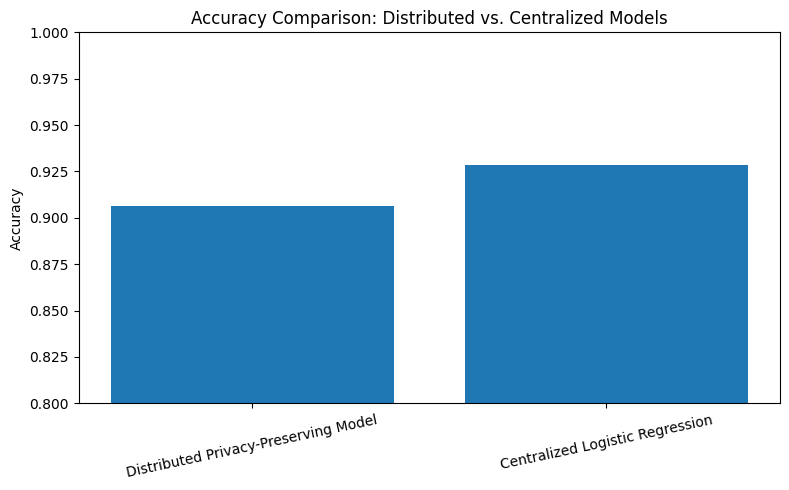

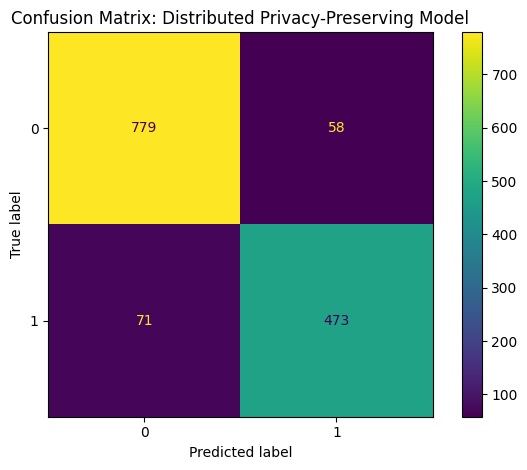


TOP 10 MOST INFLUENTIAL FEATURES
                       Feature  Coefficient
26            word_freq_george   -16.531318
24                word_freq_hp    -8.328489
34                word_freq_85    -7.556908
40                word_freq_cs    -7.347008
55  capital_run_length_longest     6.087964
33               word_freq_415    -5.513323
47        word_freq_conference    -4.604651
41           word_freq_meeting    -4.404452
45               word_freq_edu    -4.057577
48               char_freq_%3B    -3.858355


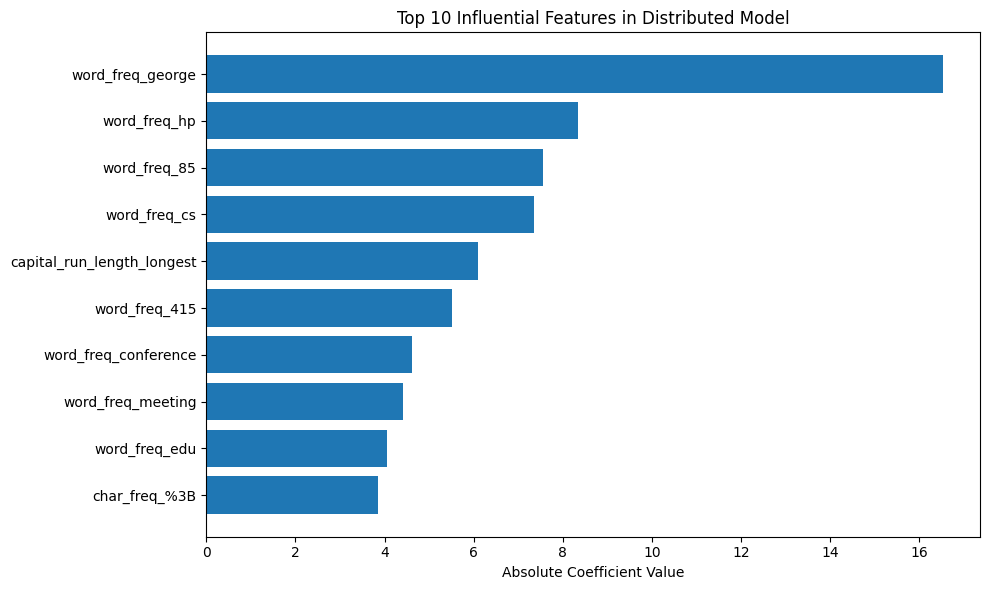


PROJECT SUMMARY
The distributed privacy-preserving model achieved an accuracy of 90.66%, compared with 92.83% for the centralized logistic regression benchmark.
Although the centralized model performed slightly better, the distributed model remained highly competitive while preserving data locality across nodes.
These findings support the feasibility of privacy-preserving distributed learning for spam classification tasks.


In [4]:
# ==============================================================
# DATA 620 PROJECT
# Privacy-Preserving Distributed Spam Classification
# Inspired by:
# Danner, Berta, and Jelasity (2018)
# "Robust Fully Distributed Minibatch Gradient Descent with Privacy Preservation"
# ==============================================================

# --------------------------------------------------------------
# 1. IMPORT LIBRARIES
# --------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --------------------------------------------------------------
# 2. LOAD AND PREPARE THE DATASET
# --------------------------------------------------------------
# The Spambase dataset contains engineered email features and a
# binary target variable indicating spam (1) or non-spam (0).

spam = fetch_openml(name="spambase", version=1, as_frame=True)

df = spam.frame.copy()
df["target"] = df["class"].astype(int)
df.drop(columns=["class"], inplace=True)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset shape: {df.shape}")
print("\nFirst five rows:")
print(df.head())

# Separate predictors and target
X = df.drop(columns=["target"])
y = df["target"]

# --------------------------------------------------------------
# 3. TRAIN-TEST SPLIT
# --------------------------------------------------------------
# A stratified split preserves the class proportions in both
# training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])

# --------------------------------------------------------------
# 4. STANDARDIZE THE FEATURES
# --------------------------------------------------------------
# Standardization improves optimization performance for gradient-
# based methods by placing features on a comparable scale.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------------------
# 5. SIMULATE A DISTRIBUTED LEARNING ENVIRONMENT
# --------------------------------------------------------------
# To approximate a distributed setting, divide the training data
# across four local nodes. Each node updates the model using only
# its local data, simulating privacy-preserving decentralized
# learning where raw data are not shared directly.

NUM_NODES = 4

# Convert y_train to NumPy to avoid future pandas warnings
y_train_array = y_train.to_numpy()

nodes_X = np.array_split(X_train_scaled, NUM_NODES)
nodes_y = np.array_split(y_train_array, NUM_NODES)

# --------------------------------------------------------------
# 6. DISTRIBUTED MINIBATCH GRADIENT DESCENT (SIMULATION)
# --------------------------------------------------------------
# This model uses SGDClassifier with logistic loss to simulate
# minibatch gradient descent in a distributed environment.
# The shared global model is updated iteratively by each node.

distributed_model = SGDClassifier(
    loss="log_loss",          # logistic regression objective
    learning_rate="optimal",
    max_iter=1,               # one pass per local update
    warm_start=True,
    random_state=RANDOM_STATE
)

classes = np.array([0, 1])
rounds = 10

print("\n" + "=" * 60)
print("DISTRIBUTED TRAINING")
print("=" * 60)

for round_num in range(rounds):
    print(f"Training round {round_num + 1}/{rounds}")

    for node_id in range(NUM_NODES):
        distributed_model.partial_fit(
            nodes_X[node_id],
            nodes_y[node_id],
            classes=classes
        )

# --------------------------------------------------------------
# 7. EVALUATE THE DISTRIBUTED MODEL
# --------------------------------------------------------------
distributed_pred = distributed_model.predict(X_test_scaled)

distributed_accuracy = accuracy_score(y_test, distributed_pred)
distributed_cm = confusion_matrix(y_test, distributed_pred)
distributed_report = classification_report(y_test, distributed_pred)

print("\n" + "=" * 60)
print("DISTRIBUTED MODEL PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {distributed_accuracy:.4f}")
print("\nClassification Report:")
print(distributed_report)

# --------------------------------------------------------------
# 8. CENTRALIZED BASELINE MODEL
# --------------------------------------------------------------
# A standard logistic regression model is trained on the full
# training dataset and serves as the centralized benchmark.

centralized_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

centralized_model.fit(X_train_scaled, y_train)
centralized_pred = centralized_model.predict(X_test_scaled)

centralized_accuracy = accuracy_score(y_test, centralized_pred)

print("\n" + "=" * 60)
print("CENTRALIZED MODEL PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {centralized_accuracy:.4f}")

# --------------------------------------------------------------
# 9. RESULTS COMPARISON TABLE
# --------------------------------------------------------------
results = pd.DataFrame({
    "Model": [
        "Distributed Privacy-Preserving Model",
        "Centralized Logistic Regression"
    ],
    "Accuracy": [
        distributed_accuracy,
        centralized_accuracy
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results)

accuracy_gap = centralized_accuracy - distributed_accuracy
print(f"\nAccuracy difference (centralized - distributed): {accuracy_gap:.4f}")

# --------------------------------------------------------------
# 10. VISUALIZATION: ACCURACY COMPARISON
# --------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0.80, 1.00)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Distributed vs. Centralized Models")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 11. VISUALIZATION: CONFUSION MATRIX
# --------------------------------------------------------------
disp = ConfusionMatrixDisplay(confusion_matrix=distributed_cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix: Distributed Privacy-Preserving Model")
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 12. FEATURE IMPORTANCE
# --------------------------------------------------------------
# For interpretability, inspect the most influential features in
# the distributed logistic model using coefficient magnitude.

feature_names = X.columns
coef_values = distributed_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef_values,
    "Absolute_Coefficient": np.abs(coef_values)
}).sort_values(by="Absolute_Coefficient", ascending=False)

top_features = feature_importance.head(10)

print("\n" + "=" * 60)
print("TOP 10 MOST INFLUENTIAL FEATURES")
print("=" * 60)
print(top_features[["Feature", "Coefficient"]])

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Absolute_Coefficient"][::-1])
plt.xlabel("Absolute Coefficient Value")
plt.title("Top 10 Influential Features in Distributed Model")
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 13. FINAL INTERPRETATION
# --------------------------------------------------------------
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(
    f"The distributed privacy-preserving model achieved an accuracy "
    f"of {distributed_accuracy:.2%}, compared with {centralized_accuracy:.2%} "
    f"for the centralized logistic regression benchmark."
)
print(
    "Although the centralized model performed slightly better, the "
    "distributed model remained highly competitive while preserving "
    "data locality across nodes."
)
print(
    "These findings support the feasibility of privacy-preserving "
    "distributed learning for spam classification tasks."
)